# Hybrid Classical–Quantum Search Demo

## Understanding Grover's Algorithm Through a Castle-Room Search Example

**Prepared by:** Swarup Sudulaganti  
**Designation:** Professor, AI & DS  
**LinkedIn:** [linkedin.com/in/sudulaganti](https://www.linkedin.com/in/sudulaganti/)  
**Implementation:** Python, Qiskit, Qiskit Aer and Jupyter Notebook  

---

### Project Overview

Imagine that a prince enters a castle to find a treasure hidden inside one of several rooms.

In a classical search, the prince may need to open the rooms one by one until the correct room is found. As the number of rooms increases, the number of checks can also increase significantly.

Quantum computing approaches the search problem differently. Instead of treating each room only as an independent possibility, a quantum circuit represents multiple possibilities using amplitudes. Grover's algorithm then uses an **oracle** and **interference** to increase the probability of measuring the room that contains the treasure.

This notebook demonstrates a simple hybrid classical–quantum search pipeline using a castle with four rooms.

---

### Learning Objectives

By the end of this notebook, we will be able to:

1. Understand how classical linear search works.
2. Represent four rooms using two qubits.
3. Create a quantum superposition of all room possibilities.
4. Use an oracle to mark the treasure room.
5. Apply interference to amplify the probability of the marked room.
6. Measure the circuit and interpret the result using classical code.
7. Understand how classical and quantum components work together in a hybrid pipeline.

---

### Search Problem

The castle contains four rooms:

| Binary State | Room Label |
| ------------ | ---------- |
| `00`         | Room 0     |
| `01`         | Room 1     |
| `10`         | Room 2     |
| `11`         | Room 3     |

For this demonstration, the treasure is hidden in:

> **Room 3**, represented by the quantum state `|11⟩`


In [1]:
# Environment verification cell

import qiskit
import qiskit_aer
import matplotlib

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

print("Environment check completed successfully.")
print("Qiskit version:", qiskit.__version__)
print("Qiskit Aer version:", qiskit_aer.__version__)
print("Matplotlib version:", matplotlib.__version__)

Environment check completed successfully.
Qiskit version: 2.3.1
Qiskit Aer version: 0.17.2
Matplotlib version: 3.10.8


## 1. Classical Search: Opening the Rooms One by One

Let us begin with the ordinary classical approach.

The castle has four rooms. The prince does not know where the treasure is hidden, so he opens the rooms one by one until he finds it.

For this demonstration, the treasure is hidden in the final room: **Room 3**.

This represents the worst-case scenario for a classical linear search because the prince must check all four rooms before finding the treasure.


In [2]:
# Classical linear search: check the rooms one by one

rooms = ["Room 0", "Room 1", "Room 2", "Room 3"]
treasure_room = "Room 3"


def classical_linear_search(room_list, target_room):
    """
    Search for the treasure by checking each room one by one.
    
    Returns:
        found_index: Position of the treasure room
        attempts: Number of rooms checked
    """
    
    attempts = 0
    
    for index, room in enumerate(room_list):
        attempts += 1
        print(f"Attempt {attempts}: Opening {room}...")
        
        if room == target_room:
            print(f"Treasure found inside {room}!")
            return index, attempts
    
    print("Treasure not found.")
    return None, attempts


found_index, attempts = classical_linear_search(rooms, treasure_room)

print("\nClassical Search Summary")
print("------------------------")
print("Treasure room index:", found_index)
print("Total rooms checked:", attempts)

Attempt 1: Opening Room 0...
Attempt 2: Opening Room 1...
Attempt 3: Opening Room 2...
Attempt 4: Opening Room 3...
Treasure found inside Room 3!

Classical Search Summary
------------------------
Treasure room index: 3
Total rooms checked: 4


## 2. Representing the Castle Rooms Using Qubits

Before applying a quantum-search algorithm, we need to represent the rooms inside a quantum circuit.

Two classical bits can represent four binary combinations:

| Binary State | Castle Room            |
| ------------ | ---------------------- |
| `00`         | Room 0                 |
| `01`         | Room 1                 |
| `10`         | Room 2                 |
| `11`         | Room 3 — Treasure Room |

In the same way, two qubits provide four computational basis states:

`|00⟩`, `|01⟩`, `|10⟩`, and `|11⟩`

Initially, the two qubits start in the state `|00⟩`.

When we apply a Hadamard gate to each qubit, the circuit creates an equal superposition of all four room states. Each room then has an equal probability of being measured.

> **Important:** Superposition does not mean that the treasure has already been found. At this stage, all four room states have equal amplitudes. If we measure now, the result will be random. Grover's algorithm will later manipulate these amplitudes to increase the probability of measuring the treasure room.


Quantum circuit used to create superposition:


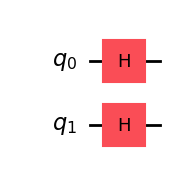

Probability of measuring each room:
|00⟩ : 0.25
|01⟩ : 0.25
|10⟩ : 0.25
|11⟩ : 0.25


In [3]:
# Create an equal superposition of all four castle rooms

from qiskit.quantum_info import Statevector
from IPython.display import display

superposition_circuit = QuantumCircuit(2)

# Apply a Hadamard gate to each qubit
superposition_circuit.h([0, 1])

print("Quantum circuit used to create superposition:")
display(superposition_circuit.draw("mpl"))

# View the quantum state before measurement
state = Statevector.from_instruction(superposition_circuit)

print("Probability of measuring each room:")
for room_state, probability in sorted(state.probabilities_dict().items()):
    print(f"|{room_state}⟩ : {probability:.2f}")

## 3. Marking the Treasure Room Using an Oracle

After creating the equal superposition, all four rooms still have the same probability of being measured.

We now need a way to identify the treasure room without directly measuring the circuit. In Grover's algorithm, this role is performed by an **oracle**.

For this demonstration, the treasure is hidden in the state:

`|11⟩`

A controlled-Z gate is used as the oracle. It changes the sign of the amplitude associated with `|11⟩`:

`+0.50 → −0.50`

The other room amplitudes remain unchanged.

> **Important:** The oracle does not increase the probability of the treasure room immediately. It only marks the correct state by changing its phase. The next stage, called the diffusion operator, will use interference to amplify the marked state.


Quantum circuit after applying the oracle:


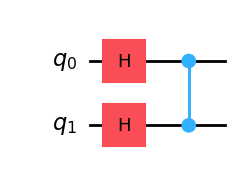

Amplitudes and probabilities after applying the oracle:
|00⟩ : amplitude = +0.50, probability = 0.25
|01⟩ : amplitude = +0.50, probability = 0.25
|10⟩ : amplitude = +0.50, probability = 0.25
|11⟩ : amplitude = -0.50, probability = 0.25


In [4]:
# Apply an oracle to mark the treasure room |11>

oracle_circuit = superposition_circuit.copy()

# The controlled-Z gate flips the phase of the |11> state
oracle_circuit.cz(0, 1)

print("Quantum circuit after applying the oracle:")
display(oracle_circuit.draw("mpl"))

# Inspect the quantum state after the oracle
oracle_state = Statevector.from_instruction(oracle_circuit)

basis_states = ["00", "01", "10", "11"]

print("Amplitudes and probabilities after applying the oracle:")
for room_state, amplitude in zip(basis_states, oracle_state.data):
    probability = abs(amplitude) ** 2
    
    print(
        f"|{room_state}⟩ : "
        f"amplitude = {amplitude.real:+.2f}, "
        f"probability = {probability:.2f}"
    )

## 4. Amplifying the Treasure Room Using the Diffusion Operator

The oracle marked the treasure room by changing the sign of its amplitude:

`|11⟩ : +0.50 → −0.50`

However, its probability is still only `0.25`. We now need to increase the probability of measuring the marked state.

Grover's algorithm uses a **diffusion operator** for this purpose. It performs an inversion around the average amplitude.

The amplitudes after the oracle are:

| Room State | Amplitude |         |
| ---------- | --------: | ------- |
| `          |      00⟩` | `+0.50` |
| `          |      01⟩` | `+0.50` |
| `          |      10⟩` | `+0.50` |
| `          |      11⟩` | `−0.50` |

The average amplitude is:

`(+0.50 + 0.50 + 0.50 − 0.50) ÷ 4 = +0.25`

Each amplitude is reflected around this average using:

`new amplitude = 2 × average amplitude − old amplitude`

The resulting amplitudes are:

| Room State | Before Diffusion | After Diffusion |         |
| ---------- | ---------------: | --------------: | ------- |
| `          |             00⟩` |         `+0.50` | `0.00`  |
| `          |             01⟩` |         `+0.50` | `0.00`  |
| `          |             10⟩` |         `+0.50` | `0.00`  |
| `          |             11⟩` |         `−0.50` | `+1.00` |

The treasure room is now strongly amplified.

> **Key idea:** The oracle marks the required state, while the diffusion operator uses interference to increase its probability. This controlled manipulation of amplitudes is the core idea behind Grover's quantum-search algorithm.


Quantum circuit after applying the diffusion operator:


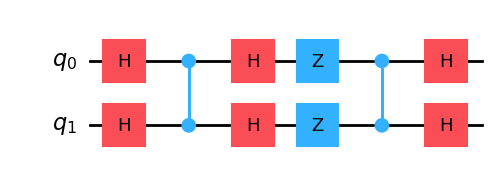

Inversion-around-the-average calculation:
Average amplitude after the oracle: +0.25

|00⟩ : +0.50  →  +0.00
|01⟩ : +0.50  →  +0.00
|10⟩ : +0.50  →  +0.00
|11⟩ : -0.50  →  +1.00

Final amplitudes and probabilities:
|00⟩ : amplitude = +0.00, probability = 0.00
|01⟩ : amplitude = +0.00, probability = 0.00
|10⟩ : amplitude = +0.00, probability = 0.00
|11⟩ : amplitude = +1.00, probability = 1.00


In [5]:
# Apply the diffusion operator to amplify the marked state |11>

grover_circuit = oracle_circuit.copy()

# Compact two-qubit diffusion operator
# H gates: move into the Hadamard basis
# Z and CZ gates: perform the reflection
# H gates: return to the computational basis
grover_circuit.h([0, 1])
grover_circuit.z([0, 1])
grover_circuit.cz(0, 1)
grover_circuit.h([0, 1])

print("Quantum circuit after applying the diffusion operator:")
display(grover_circuit.draw("mpl"))


# Helper function to remove tiny floating-point values such as -0.00
def clean_number(value, tolerance=1e-10):
    return 0.0 if abs(value) < tolerance else float(value)


# Explain the inversion-around-the-average calculation
oracle_amplitudes = [
    clean_number(amplitude.real)
    for amplitude in oracle_state.data
]

average_amplitude = sum(oracle_amplitudes) / len(oracle_amplitudes)

print("Inversion-around-the-average calculation:")
print(f"Average amplitude after the oracle: {average_amplitude:+.2f}\n")

for room_state, old_amplitude in zip(basis_states, oracle_amplitudes):
    new_amplitude = clean_number(
        (2 * average_amplitude) - old_amplitude
    )
    
    print(
        f"|{room_state}⟩ : "
        f"{old_amplitude:+.2f}  →  {new_amplitude:+.2f}"
    )


# Inspect the actual final quantum state
amplified_state = Statevector.from_instruction(grover_circuit)

print("\nFinal amplitudes and probabilities:")
for room_state, amplitude in zip(basis_states, amplified_state.data):
    cleaned_amplitude = clean_number(amplitude.real)
    probability = clean_number(abs(amplitude) ** 2)
    
    print(
        f"|{room_state}⟩ : "
        f"amplitude = {cleaned_amplitude:+.2f}, "
        f"probability = {probability:.2f}"
    )

## 5. Measuring the Quantum Circuit

The treasure-room state has now been amplified:

`|11⟩ : probability = 1.00`

We can now measure the qubits.

Measurement converts the quantum result into classical bits that can be processed by ordinary Python code. We will run the circuit multiple times using a local simulator. Each run is called a **shot**.

Because the treasure state has been amplified successfully, the measured result should be:

`11`

This binary result corresponds to:

> **Room 3 — Treasure Room**

The final stage demonstrates the hybrid nature of the pipeline:

1. Classical code defines the room labels and prepares the problem.
2. The quantum circuit creates superposition, marks the target and amplifies its probability.
3. Classical code reads the measurement counts and converts the binary result into a room label.


Final Grover circuit with measurement:


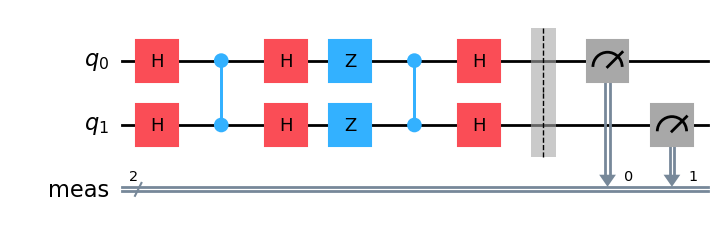

Measurement counts:
{'11': 1024}

Hybrid Search Result
--------------------
Most frequently measured state: 11
Interpreted classical result: Room 3 — Treasure Room


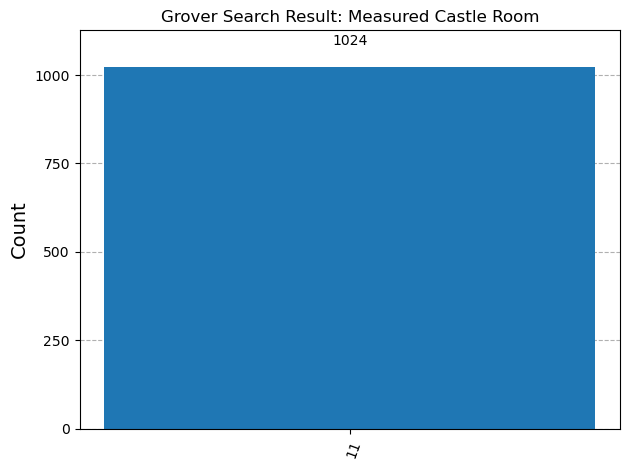

In [6]:
# Measure the amplified quantum state and interpret the result

measurement_circuit = grover_circuit.copy()

# Measure all qubits and store the outcomes in classical bits
measurement_circuit.measure_all()

print("Final Grover circuit with measurement:")
display(measurement_circuit.draw("mpl"))

# Create a local ideal simulator
simulator = AerSimulator()

# Prepare the circuit for the selected simulator
compiled_circuit = transpile(measurement_circuit, simulator)

# Run the circuit multiple times
shots = 1024
simulation_result = simulator.run(
    compiled_circuit,
    shots=shots
).result()

# Retrieve the measured bit strings
counts = simulation_result.get_counts()

print("Measurement counts:")
print(counts)

# Identify the most frequently measured state
most_frequent_state = max(counts, key=counts.get)

room_lookup = {
    "00": "Room 0",
    "01": "Room 1",
    "10": "Room 2",
    "11": "Room 3 — Treasure Room"
}

print("\nHybrid Search Result")
print("--------------------")
print("Most frequently measured state:", most_frequent_state)
print("Interpreted classical result:", room_lookup[most_frequent_state])

# Display a histogram of the measurement outcomes
display(plot_histogram(
    counts,
    title="Grover Search Result: Measured Castle Room"
))

## 6. Understanding the Hybrid Classical–Quantum Pipeline

This project is not purely classical and it is not purely quantum. It is a simple **hybrid classical–quantum pipeline**.

A practical quantum-computing workflow usually combines classical programming with quantum circuits.

| Stage                        | Computing Type | Role in This Demonstration                                    |
| ---------------------------- | -------------- | ------------------------------------------------------------- |
| Define the castle rooms      | Classical      | Create the room labels using Python                           |
| Select the treasure room     | Classical      | Define the target search problem                              |
| Prepare the qubits           | Quantum        | Represent the four possible rooms                             |
| Create superposition         | Quantum        | Give all four room states equal amplitudes                    |
| Apply the oracle             | Quantum        | Mark the treasure-room state using a phase change             |
| Apply the diffusion operator | Quantum        | Amplify the probability of the marked state                   |
| Measure the qubits           | Quantum        | Convert the final quantum state into classical bits           |
| Interpret the result         | Classical      | Convert the measured state `11` into `Room 3 — Treasure Room` |
| Display the histogram        | Classical      | Visualize the measured outcomes                               |

### Key Observation

The quantum circuit does not simply open every room one by one.

Instead:

1. Superposition prepares the possible room states.
2. The oracle marks the correct state.
3. Interference changes the amplitudes.
4. The diffusion operator increases the probability of the marked state.
5. Measurement returns the most likely answer.
6. Classical Python code interprets the measured result.

This small example demonstrates the basic structure used in many hybrid quantum applications:

> **Classical preparation → Quantum processing → Classical interpretation**


## 7. Classical Search vs. Grover Search

The four-room example is intentionally small so that each quantum operation can be understood clearly.

However, the real advantage of Grover's algorithm becomes more visible as the search space increases.

For a search space containing `N` possible rooms:

* A classical linear search may require up to `N` checks in the worst case.
* Grover's quantum-search algorithm requires approximately `√N` oracle iterations for one marked item.

The following comparison uses a few example search-space sizes.

> **Note:** The values below are approximate Grover-iteration counts for teaching purposes. The exact number of iterations depends on the number of possible states and the number of marked solutions.


Search Complexity Comparison
----------------------------
   Rooms | Classical checks |  Grover iterations
--------------------------------------------------
       4 |                4 |                  1
      16 |               16 |                  3
      64 |               64 |                  6
     256 |              256 |                 12
    1024 |             1024 |                 25


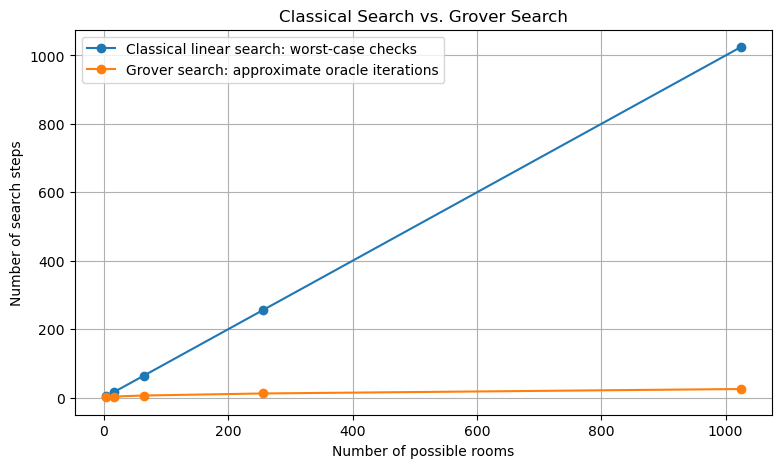

In [7]:
# Compare classical worst-case checks with approximate Grover iterations

import math
import matplotlib.pyplot as plt

search_space_sizes = [4, 16, 64, 256, 1024]

classical_checks = search_space_sizes

grover_iterations = [
    max(1, math.floor((math.pi / 4) * math.sqrt(number_of_rooms)))
    for number_of_rooms in search_space_sizes
]

print("Search Complexity Comparison")
print("----------------------------")
print(f"{'Rooms':>8} | {'Classical checks':>16} | {'Grover iterations':>18}")
print("-" * 50)

for rooms_count, classical, grover in zip(
    search_space_sizes,
    classical_checks,
    grover_iterations
):
    print(f"{rooms_count:>8} | {classical:>16} | {grover:>18}")


# Visual comparison
plt.figure(figsize=(9, 5))

plt.plot(
    search_space_sizes,
    classical_checks,
    marker="o",
    label="Classical linear search: worst-case checks"
)

plt.plot(
    search_space_sizes,
    grover_iterations,
    marker="o",
    label="Grover search: approximate oracle iterations"
)

plt.title("Classical Search vs. Grover Search")
plt.xlabel("Number of possible rooms")
plt.ylabel("Number of search steps")
plt.legend()
plt.grid(True)
plt.show()

### Interpreting the Comparison

The graph shows that Grover's algorithm can reduce the number of search steps required for an unstructured-search problem.

For `N` possible rooms:

| Search Method           | Approximate Worst-Case Search Complexity |
| ----------------------- | ---------------------------------------- |
| Classical linear search | `O(N)`                                   |
| Grover's quantum search | `O(√N)`                                  |

This represents a **quadratic speedup**.

For example:

| Number of Possible Rooms | Classical Worst-Case Checks | Approximate Grover Iterations |
| -----------------------: | --------------------------: | ----------------------------: |
|                        4 |                           4 |                             1 |
|                       16 |                          16 |                             3 |
|                       64 |                          64 |                             6 |
|                      256 |                         256 |                            12 |
|                     1024 |                        1024 |                            25 |

### Important Clarification

This notebook demonstrates the logic of Grover's algorithm using a local simulator.

The graph compares the number of search steps or oracle calls. It does **not** compare the actual execution time on the current computer. A simulator uses classical hardware to reproduce quantum-circuit behaviour.

In a practical quantum-computing system, factors such as circuit depth, oracle construction, hardware noise and error rates must also be considered.

> **Key takeaway:** Grover's algorithm does not provide an exponential speedup. It provides a valuable quadratic improvement for suitable unstructured-search problems.


## 8. Classroom Practice Activity

Use the following questions to check your understanding of the quantum-search workflow.

### Part A — Concept Check

1. Why do we apply Hadamard gates before using the oracle?
2. What happens to the amplitude of the treasure-room state after applying the oracle?
3. Why does the probability of the treasure room remain unchanged immediately after the oracle?
4. What is the purpose of the diffusion operator?
5. Why do we need classical Python code after measuring the quantum circuit?

---

### Part B — Manual Amplitude Exercise

Assume that the treasure is hidden in `|11⟩`.

After creating an equal superposition, the amplitudes are:

| Room State | Initial Amplitude |         |
| ---------- | ----------------: | ------- |
| `          |              00⟩` | `+0.50` |
| `          |              01⟩` | `+0.50` |
| `          |              10⟩` | `+0.50` |
| `          |              11⟩` | `+0.50` |

After applying the oracle:

| Room State | Amplitude After Oracle |         |
| ---------- | ---------------------: | ------- |
| `          |                   00⟩` | `+0.50` |
| `          |                   01⟩` | `+0.50` |
| `          |                   10⟩` | `+0.50` |
| `          |                   11⟩` | `−0.50` |

Answer the following:

1. Calculate the average amplitude after applying the oracle.

2. Apply the formula:

   `new amplitude = 2 × average amplitude − old amplitude`

3. Verify that the treasure-room state becomes strongly amplified.

---

### Part C — Small Coding Experiment

Run the measurement cell again after changing:

```python
shots = 1024
```

to:

```python
shots = 100
```

Observe the measurement counts.

Then try:

```python
shots = 10
```

### Question

Does changing the number of shots change the treasure room identified by the circuit in this ideal two-qubit example?

---

### Optional Extension

The current notebook marks `|11⟩` using a controlled-Z gate.

As a further activity, explore how the oracle should be modified if the treasure is hidden in another room, such as:

* `|00⟩`
* `|01⟩`
* `|10⟩`

This extension helps us understand that an oracle must be designed according to the target state.


## 9. Conclusion and Reflection

### Conclusion

This notebook demonstrated a simple hybrid classical–quantum search pipeline using Grover's algorithm.

The search problem was explained using a castle-room example:

* The castle contained four possible rooms.
* The treasure was hidden in `Room 3`, represented by the quantum state `|11⟩`.
* Classical linear search required four room checks in the worst-case scenario.
* The quantum circuit represented all four rooms using two qubits.
* Hadamard gates created an equal superposition of the possible room states.
* The oracle marked the treasure-room state by changing its phase.
* The diffusion operator amplified the probability of the marked state through interference.
* Measurement returned the binary result `11`.
* Classical Python code converted the result into `Room 3 — Treasure Room`.

The workflow can be summarized as:

> **Classical preparation → Quantum processing → Classical interpretation**

---

### What I Learned

Before preparing this demonstration, the role of amplitudes in quantum computing appeared abstract.

This small example helped clarify the purpose of amplitude manipulation:

1. Superposition creates multiple possible states with equal amplitudes.
2. The oracle does not directly reveal the answer; it marks the required state by changing its phase.
3. The diffusion operator uses interference to amplify the marked state.
4. Measurement converts the final quantum state into a classical result.

The main learning point is that quantum computing is not simply about checking every possibility at the same time. Its practical advantage comes from designing quantum operations that increase the probability of measuring useful answers.

---

### Teaching Reflection

This notebook can be used as an introductory classroom demonstration for students learning quantum computing.

The castle-room analogy provides a simple entry point for explaining:

* binary state representation;
* qubits and superposition;
* quantum amplitudes;
* phase marking;
* interference;
* measurement;
* Grover's algorithm;
* hybrid classical–quantum workflows.

The example is intentionally small so that every operation can be explained step by step. After understanding the four-room example, students can explore larger search spaces and more advanced oracle designs.

---

### Final Takeaway

> Quantum algorithms become useful not merely because they represent multiple possibilities, but because they manipulate amplitudes so that useful answers become more likely during measurement.
